In [2]:
import matplotlib.pyplot as plt
plt.rcParams.update({"text.usetex": True,
                     "axes.spines.right" : False,
                     "axes.spines.top" : False,
                     "font.size": 15,
                     "savefig.dpi": 400,
                     "savefig.bbox": 'tight',
                     'text.latex.preamble': r'\usepackage{amsfonts}'
                    }
                   )

import geomstats.backend as gs
import numpy as np

INFO: Using numpy backend


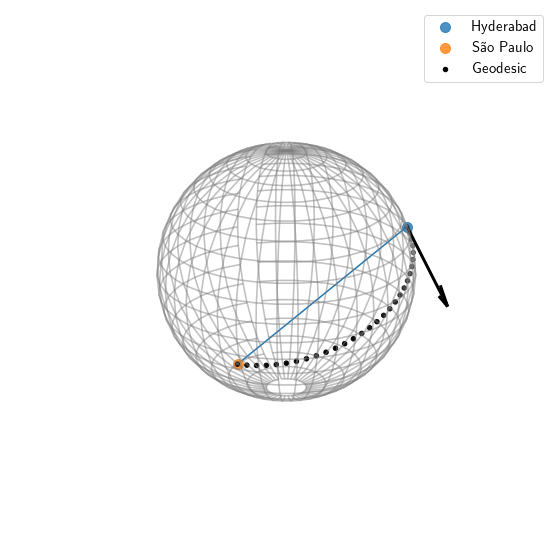

In [3]:
from geomstats.geometry.hypersphere import Hypersphere
import geomstats.datasets.utils as data_utils
import geomstats.visualization as viz
S2 = Hypersphere(dim=2)
data, names = data_utils.load_cities()
hyd = (data[41,:], 'Hyderabad')
sp = (data[4,:], 'São Paulo')
geodesic = S2.metric.geodesic(
        initial_point=hyd[0],
        end_point=sp[0])
points_on_geodesic = geodesic(gs.linspace(0., 1., 30))
log = S2.metric.log(point=sp[0], base_point=hyd[0])

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax = viz.plot(hyd[0], ax=ax, space='S2', s=100, alpha=0.8, label=hyd[1])
ax = viz.plot(sp[0], ax=ax, space='S2', s=100, alpha=0.8, label=sp[1])
ax = viz.plot(points_on_geodesic, ax=ax, space='S2', color='black', label='Geodesic')
vector = np.vstack((hyd[0],sp[0]))
ax.plot(vector[:,0],vector[:,1],vector[:,2])
arrow = viz.Arrow3D(hyd[0], vector=log)
arrow.draw(ax, color='black', lw=3.0, normalize=True,arrow_length_ratio=0.2)
ax.legend()
ax.view_init(elev=23., azim=157)
ax.axis('off')
#plt.savefig('../figures/011122/S2.png')
plt.show()

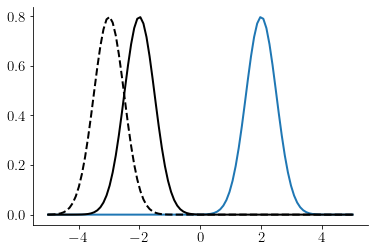

In [5]:
N_SAMPLES = 100
lambda_ = np.linspace(-5,5,num=N_SAMPLES)
def gaussian(mu,sig):
    scale = 1/(np.sqrt(2*np.pi)*sig)
    return scale*np.exp(-np.power(lambda_ - mu, 2.) / (2 * np.power(sig, 2.)))

fig, ax = plt.subplots()
y0 = gaussian(2,0.5)
y1 = gaussian(-3,0.5)
y2 = gaussian(-2,0.5)
ax.plot(lambda_, y0, lw=2.0)
ax.plot(lambda_, y1, ls='--', color='k', lw=2.0)
ax.plot(lambda_, y2, color='k', lw=2.0)
plt.show()

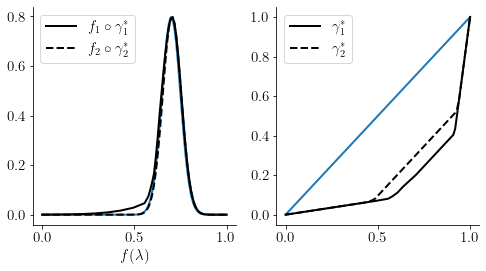

In [14]:
import fdasrsf as fs

time = np.linspace(0,1,N_SAMPLES)
f1n, gam1,_ = fs.pairwise_align_functions(y0,y1,time)
f2n, gam2,_ = fs.pairwise_align_functions(y0,y2,time)
fig, axs = plt.subplots(1,2,figsize=(2*4,4))
axs[0].plot(time, y0, lw=2.0)
axs[0].plot(time, f1n,label=r'$f_{1}\circ\gamma_{1}^{*}$',color='k', lw=2.0)
axs[0].plot(time, f2n,label=r'$f_{2}\circ\gamma_{2}^{*}$',ls='--', color='k', lw=2.0)
axs[0].legend()
axs[0].set_xlabel(r'$\lambda$')
axs[0].set_xlabel(r'$f(\lambda)$')

axs[1].plot(time, time,lw=2.0)
axs[1].plot(time, gam1,color='k', lw=2.0, label=r'$\gamma_{1}^{*}$')
axs[1].plot(time, gam2,ls='--', color='k', lw=2.0, label=r'$\gamma_{2}^{*}$')
axs[1].legend()
plt.savefig('../figures/011122/srsf.png')
plt.show()